In [1]:

import pickle
import os
import mat73
import torch
import scipy.io as sio
import yaml
from pathlib import Path
from config.config import Config
import numpy as np
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
import DecayFitNet.python.toolbox as decayfitnet
from DecayFitNet.python.toolbox.utils import calc_mse


Load parameters from Georg's dataset 

In [2]:
dataset_path = "/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/Common_Slope_Analysis_Results"
# pick one random file from the dataset 
filepath = "cs_analysis_results_omni_1000.mat"
# read the mat file 
data = mat73.loadmat(os.path.join(dataset_path, filepath))['analysisResults']
# load the impulse responses 
srirs = mat73.loadmat("/Users/dalsag1/Documents/datasets/Georg_3room_FDTD/srirs.mat")['srirDataset']


In [3]:

fs = srirs['fs'].item() # sampling frequnecy
L = srirs['srirs'].shape[1] # length of the impulse responses

In [4]:
loc_indx = 100   # location index [0, 838]
ref_rir = srirs['srirs'][loc_indx, :]    # assuming that the omnidirectional is the first channel

In [5]:
from slope2noise.utils import schroeder_backward_int
from slope2noise.dataclass import *
from slope2noise.generate import *
time_axis = np.arange(0, L) / fs

# DecayFitNet finds the optimal number of slopes and set the rest to zero
valid_slopes =  np.nonzero(data['tVals_standard'][loc_indx, :])[0]

isStandard = False
if isStandard: 
    t_vals = data['tVals_standard'][loc_indx, valid_slopes] 
    a_vals =  data['aVals_standard'][loc_indx, valid_slopes] 
    n_vals = data['nVals_standard'][loc_indx] 
else: 
    t_vals = data['commonDecayTimes'] 
    a_vals =  data['aVals'][loc_indx, ...] 
    n_vals = data['nVals'][loc_indx]

_, rirs = shaped_wgn(np.expand_dims(t_vals,  (0, -1)),
                    np.expand_dims(a_vals,  (0, -1)),
                    np.expand_dims(n_vals,  (0, -1))*L,
                    fs=fs,
                    ir_len=L,
                    )

envelope_kernel = decay_kernel( np.expand_dims(t_vals,  (0)),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=True)

# add noise to a vals
a_vals_noise = np.concatenate((a_vals, np.expand_dims(n_vals, axis=-1)), axis=-1)
edc = a_vals_noise*envelope_kernel

# use decayfitnet
edc_decayfitnet = decayfitnet.core.decay_kernel(np.expand_dims(t_vals,  0), time_axis)

# edc_decayfitnet = np.delete(edc_decayfitnet, -1, axis=1)  # throw away noise term
a_vals_noise = np.concatenate((a_vals, np.expand_dims(n_vals, axis=-1)), axis=-1)
edc_decayfitnet = np.dot(edc_decayfitnet, a_vals_noise)

og_edc_decayfitnet = decayfitnet.core.decay_model(torch.from_numpy(np.expand_dims(t_vals, (0 ))),
                                                        torch.from_numpy(np.expand_dims(a_vals, (0))),
                                                        torch.from_numpy(np.expand_dims(np.array(n_vals), (0))),
                                                        time_axis=torch.from_numpy(time_axis),
                                                        compensate_uli=False,
                                                        backend='torch').squeeze()

2025-02-27 11:40:36.983 | INFO     | slope2noise.generate:shaped_wgn:86 - Done with kernel generation for slope 1
2025-02-27 11:40:36.999 | INFO     | slope2noise.generate:shaped_wgn:86 - Done with kernel generation for slope 2
2025-02-27 11:40:37.002 | INFO     | slope2noise.generate:shaped_wgn:86 - Done with kernel generation for slope 3
2025-02-27 11:40:37.005 | INFO     | slope2noise.generate:shaped_wgn:86 - Done with kernel generation for slope 4


Compare for the BROADBAND case
* EDC computed from Schroeder Backward integration of the shaped noise 
* EDC computed from Schroeder Backward integration of the reference 
* EDC constructed from the Common slope parameters using slope2noise
* EDC constructed from the Common slope parameters using DecayFitNet

/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_75934/1267414790.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.plot(time_axis, 10*np.log10(ref_int), label='ref EDC')
/var/folders/3l/7_dsnxg54ngcd4f6xxw46mvr0000gp/T/ipykernel_75934/1267414790.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(time_axis, 10*np.log10(og_edc_decayfitnet), '-.', label='OG Decay Fit net common slope EDC')


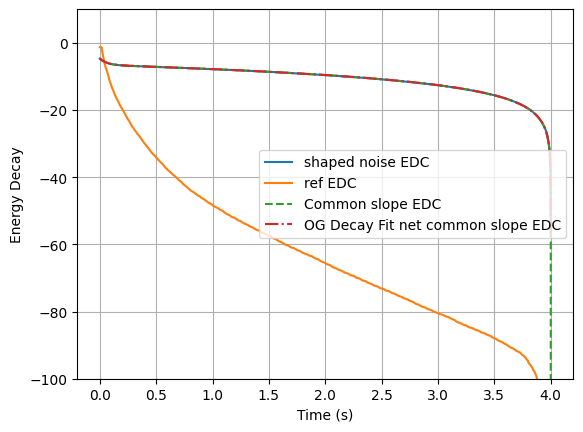

tensor(130.3204, dtype=torch.float64)


In [6]:
import torch 

left_crop = int(fs*0.020)
right_crop = int(fs*0.005)
# sn_int = schroeder_backward_int(rirs.squeeze()[left_crop:-right_crop], normalize=False)
# ref_int = schroeder_backward_int(ref_rir[left_crop:(-right_crop), 0].squeeze(), normalize=False)
sn_int = schroeder_backward_int(rirs.squeeze(), normalize=False)
ref_int = schroeder_backward_int(ref_rir[:, 0].squeeze(), normalize=False)

# pad ref_init 
if len(ref_int) < len(sn_int):
    ref_int = np.pad(ref_int, (0, 1))
# TODO: apply filter bank and sum the bands to get the EDC

plt.plot(time_axis, 10*np.log10(sn_int), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(ref_int), label='ref EDC')
plt.plot(time_axis, 10*np.log10(edc.sum(-1).squeeze()), '--', label='Common slope EDC')
# plt.plot(time_axis, 10*np.log10(edc_decayfitnet), '-.', label='Decay Fit net common slope EDC')
plt.plot(time_axis, 10*np.log10(og_edc_decayfitnet), '-.', label='OG Decay Fit net common slope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()

loss_fn = torch.nn.MSELoss()
this_mse = loss_fn(10 * torch.log10(torch.tensor(np.expand_dims(ref_int[:-int(0.05*L)], (0, -1)))), 
                   10 * torch.log10(torch.tensor(np.expand_dims(edc_decayfitnet[:-int(0.05*L)], (0, -1)))))
print(this_mse)
